# July 2025 Missing-Aware Column Vecchia Fit

This notebook uses the new `GEMS_TCO.vecchia_candidate.vecchia_real_data_intersection_template_reuse` helpers.

Design choice:

- Raw GEMS grid order is checked as east-to-west within a latitude row, then north-to-south.
- Keys are grouped by parsed calendar day; days with fewer or more than 8 hourly frames are skipped.
- For each complete 8-hour day, locations missing in any hour are moved to the late part of the scan order and truncated by default.
- The fitted support is therefore the 8-hour nonmissing intersection.
- The conditioning template is built on regular grid locations.  `PER_LAG_M=60` is applied separately to t, t-1, and t-2, so interior tail targets can use up to 180 conditioning neighbors.
- Template reuse is valid only when the reverse-L relative displacement vectors are computed on the regular grid. Using original source locations changes those displacement vectors by target/hour, so that should use a batched non-template-reuse kernel instead.


In [1]:
import sys
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '/Users/joonwonlee/Documents/GEMS_TCO-1/src')

from GEMS_TCO.vecchia_candidate.vecchia_real_data_intersection_template_reuse import (
    diagnose_scan_order,
    make_day_intersection_input_map,
    make_st_initial_params,
    ReverseLIntersectionColumnVecchiaFit,
)

DTYPE = torch.float64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)


DEVICE = cpu


In [2]:
DATA_PATH = Path('/Users/joonwonlee/Documents/GEMS_DATA/pickle_2025/tco_grid_25_07.pkl')
assert DATA_PATH.exists(), DATA_PATH

raw_map = pd.read_pickle(DATA_PATH)
keys = sorted(raw_map.keys())
print('n hourly frames:', len(keys))
print('first keys:', keys[:3])
print(raw_map[keys[0]].head())

KEY_RE = re.compile(r'y(?P<year>\d{2})m(?P<month>\d{2})day(?P<day>\d{2})_hm(?P<hm>.+)$')

def parse_key(key):
    match = KEY_RE.match(str(key))
    if match is None:
        raise ValueError(f'Unrecognized key format: {key}')
    out = match.groupdict()
    out['year'] = 2000 + int(out['year'])
    out['month'] = int(out['month'])
    out['day'] = int(out['day'])
    return out

key_info = {k: parse_key(k) for k in keys}
DATA_YEAR = key_info[keys[0]]['year']
DATA_MONTH = key_info[keys[0]]['month']

keys_by_day = defaultdict(list)
for key in keys:
    keys_by_day[key_info[key]['day']].append(key)
keys_by_day = {day: sorted(ks) for day, ks in sorted(keys_by_day.items())}
COMPLETE_DAY_IDXS = [day - 1 for day, ks in keys_by_day.items() if len(ks) == 8]
SKIPPED_DAY_COUNTS = {day: len(ks) for day, ks in keys_by_day.items() if len(ks) != 8}

print('data month:', f'{DATA_YEAR:04d}-{DATA_MONTH:02d}')
print('complete 8-hour days:', [d + 1 for d in COMPLETE_DAY_IDXS])
print('skipped non-8-hour days:', SKIPPED_DAY_COUNTS)

scan_diag = diagnose_scan_order(raw_map[keys[0]])
scan_diag


n hourly frames: 247
first keys: ['y25m07day01_hm00:53', 'y25m07day01_hm01:53', 'y25m07day01_hm02:53']
   Latitude  Longitude  ColumnAmountO3  Hours_elapsed  Source_Latitude  \
0       2.0    131.000             NaN            NaN              NaN   
1       2.0    130.937             NaN            NaN              NaN   
2       2.0    130.874             NaN            NaN              NaN   
3       2.0    130.811             NaN            NaN              NaN   
4       2.0    130.748             NaN            NaN              NaN   

   Source_Longitude  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  
data month: 2025-07
complete 8-hour days: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31]
skipped non-8-hour days: {24: 7}


{'ok': True,
 'n_rows_detected': 114,
 'row_length_median': 159.0,
 'row_length_min': 159,
 'row_length_max': 159,
 'within_row_westward': True,
 'north_to_south': True,
 'first_coords': [(2.0, 131.0),
  (2.0, 130.937),
  (2.0, 130.87400000000002),
  (2.0, 130.81100000000004),
  (2.0, 130.74800000000005),
  (2.0, 130.68500000000006),
  (2.0, 130.62200000000007),
  (2.0, 130.55900000000008)],
 'first_reset_index': 159}

In [3]:
# Monthly centering, matching the existing day Vecchia data loader convention.
monthly_mean = float(np.nanmean(np.concatenate([
    pd.to_numeric(df['ColumnAmountO3'], errors='coerce').to_numpy(dtype=float)
    for df in raw_map.values()
])))
monthly_mean


241.44122884766566

In [4]:
def date_for_day_idx(day_idx):
    day = int(day_idx) + 1
    return f'{DATA_YEAR:04d}-{DATA_MONTH:02d}-{day:02d}'


def day_keys(day_idx):
    """Return keys for complete 8-hour days; incomplete days are skipped."""
    day = int(day_idx) + 1
    ks = keys_by_day.get(day, [])
    return ks if len(ks) == 8 else []


def make_day_map(day_idx, coord_mode='grid', compact_intersection_grid=True):
    """Build one-day input map.

    With compact_intersection_grid=True, the 8-hour intersection observations are
    first ordered like raw GEMS scan order (north row, east-to-west, then south)
    and then packed onto a hole-free regular grid before reverse-L conditioning.
    This is the intended template-reuse experiment.
    """
    ks = day_keys(day_idx)
    if len(ks) != 8:
        raise ValueError(f'{date_for_day_idx(day_idx)} has {len(ks)} hourly frames; expected 8')
    return make_day_intersection_input_map(
        {k: raw_map[k] for k in ks},
        monthly_mean=monthly_mean,
        coord_mode=coord_mode,
        require_source_coordinates=True,
        truncate_to_intersection=True,
        compact_intersection_grid=compact_intersection_grid,
        dtype=DTYPE,
        device=DEVICE,
    )

# Missing/intersection diagnostics for complete 8-hour July days.
diag_rows = []
for d in COMPLETE_DAY_IDXS:
    res = make_day_map(d, coord_mode='grid', compact_intersection_grid=True)
    row = {'day_idx': d, 'date': date_for_day_idx(d), **res.diagnostics}
    row['min_hour_valid'] = min(row['per_hour_valid'])
    row['max_hour_valid'] = max(row['per_hour_valid'])
    diag_rows.append(row)


diag_df = pd.DataFrame(diag_rows)
show_cols = [
    'date', 'n_grid_total', 'n_intersection', 'n_late_or_dropped',
    'intersection_fraction', 'compact_intersection_grid', 'packed_grid_n_rows',
    'packed_grid_n_lon', 'packed_last_row_count', 'min_hour_valid', 'max_hour_valid'
]
diag_df[show_cols]


,date,n_grid_total,n_intersection,n_late_or_dropped,intersection_fraction,compact_intersection_grid,packed_grid_n_rows,packed_grid_n_lon,packed_last_row_count,min_hour_valid,max_hour_valid
0,2025-07-01,18126,12715,5411,0.701479,True,80,159,154,16136,17435
1,2025-07-02,18126,9276,8850,0.511751,True,59,159,54,14602,17031
2,2025-07-03,18126,16936,1190,0.934348,True,107,159,82,17500,18062
3,2025-07-04,18126,15843,2283,0.874048,True,100,159,102,17054,17884
4,2025-07-05,18126,16148,1978,0.890875,True,102,159,89,17276,17969
5,2025-07-06,18126,14252,3874,0.786274,True,90,159,101,16912,17759
6,2025-07-07,18126,10238,7888,0.564824,True,65,159,62,15029,17268
7,2025-07-08,18126,16897,1229,0.932197,True,107,159,43,17718,18007
8,2025-07-09,18126,13453,4673,0.742194,True,85,159,97,16255,17527
9,2025-07-10,18126,15212,2914,0.839236,True,96,159,107,17216,17727


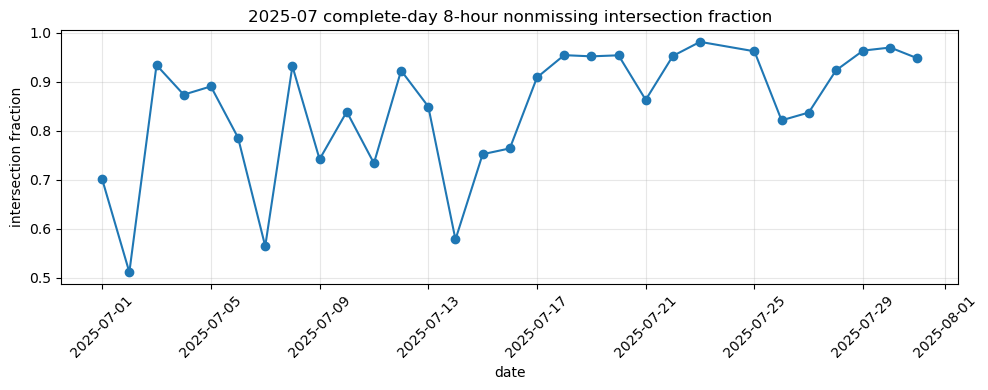

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pd.to_datetime(diag_df['date']), diag_df['intersection_fraction'], marker='o')
ax.set_title(f'{DATA_YEAR:04d}-{DATA_MONTH:02d} complete-day 8-hour nonmissing intersection fraction')
ax.set_ylabel('intersection fraction')
ax.set_xlabel('date')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
SMOOTH = 0.5
HEAD_RIGHT_COLS = 3
ABOVE_COUNT = 4
RIGHT_COL_COUNT = 3
PER_LAG_M = 60      # spatial conditioning cap per lag: t, t-1, t-2 each get up to 60
LAG_COUNT = 2       # use current hour plus two previous hours
LBFGS_STEPS = 20
LBFGS_EVAL = 5
TARGET_CHUNK_SIZE = 2048

# For a quick smoke test, use [0].  For the full month, use COMPLETE_DAY_IDXS.
DAYS_TO_FIT = [2]
# DAYS_TO_FIT = COMPLETE_DAY_IDXS


In [7]:
def tensor_float(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    return float(x)

def fit_one_day(day_idx):
    res = make_day_map(day_idx, coord_mode='grid', compact_intersection_grid=True)
    params = make_st_initial_params(
        sigmasq=10.0,
        range_lat=0.3,
        range_lon=0.4,
        range_time=2.0,
        advec_lat=0.08,
        advec_lon=-0.16,
        nugget=2.5,
        device=DEVICE,
        dtype=DTYPE,
    )
    model = ReverseLIntersectionColumnVecchiaFit(
        smooth=SMOOTH,
        input_map=res.input_map,
        grid_coords=res.grid_coords,
        head_right_cols=HEAD_RIGHT_COLS,
        above_count=ABOVE_COUNT,
        right_col_count=RIGHT_COL_COUNT,
        per_lag_conditioning_count=PER_LAG_M,
        lag_count=LAG_COUNT,
        include_lag_self=False,
        target_chunk_size=TARGET_CHUNK_SIZE,
    )
    model.precompute_conditioning_sets()
    conditioning_summary = dict(model.conditioning_summary)
    opt = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=10)
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    raw = [tensor_float(x) for x in out[:-1]]
    loss = tensor_float(out[-1])
    est = model._convert_params(raw)
    row = {
        'day_idx': int(day_idx),
        'date': date_for_day_idx(day_idx),
        'n_hours': len(day_keys(day_idx)),
        'first_key': day_keys(day_idx)[0],
        'last_key': day_keys(day_idx)[-1],
        'loss': loss,
        'fit_iter': int(fit_iter),
        'n_intersection': int(res.diagnostics['n_intersection']),
        'intersection_fraction': float(res.diagnostics['intersection_fraction']),
        'n_heads': int(model.Heads_data.shape[0]),
        'n_tails': int(model.n_tails),
        'n_templates': int(conditioning_summary.get('template_count', len(model.Grouped_Batches))),
        'template_reuse_count': int(conditioning_summary.get('template_count', len(model.Grouped_Batches))),
        'template_targets_mean': float(conditioning_summary.get('template_targets_mean', np.nan)),
        'template_targets_median': float(conditioning_summary.get('template_targets_median', np.nan)),
        'template_targets_max': int(conditioning_summary.get('template_targets_max', 0)),
        'head_right_cols': HEAD_RIGHT_COLS,
        'above_count': ABOVE_COUNT,
        'right_col_count': RIGHT_COL_COUNT,
        'per_lag_m': PER_LAG_M,
        'lag_count': LAG_COUNT,
        'conditioning_total_cap': int(conditioning_summary.get('conditioning_total_cap', PER_LAG_M * (LAG_COUNT + 1))),
        'conditioning_m_mean': float(conditioning_summary.get('conditioning_m_mean', np.nan)),
        'conditioning_m_median': float(conditioning_summary.get('conditioning_m_median', np.nan)),
        'conditioning_m_max': int(conditioning_summary.get('conditioning_m_max', 0)),
        'conditioning_t_mean': float(conditioning_summary.get('conditioning_t_mean', np.nan)),
        'conditioning_t_median': float(conditioning_summary.get('conditioning_t_median', np.nan)),
        'conditioning_t_max': int(conditioning_summary.get('conditioning_t_max', 0)),
        'conditioning_tminus1_mean': float(conditioning_summary.get('conditioning_t-1_mean', np.nan)),
        'conditioning_tminus1_median': float(conditioning_summary.get('conditioning_t-1_median', np.nan)),
        'conditioning_tminus1_max': int(conditioning_summary.get('conditioning_t-1_max', 0)),
        'conditioning_tminus2_mean': float(conditioning_summary.get('conditioning_t-2_mean', np.nan)),
        'conditioning_tminus2_median': float(conditioning_summary.get('conditioning_t-2_median', np.nan)),
        'conditioning_tminus2_max': int(conditioning_summary.get('conditioning_t-2_max', 0)),
        **est,
    }
    del model, params, opt
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return row


In [8]:
fit_rows = []
for d in DAYS_TO_FIT:
    print(f'\n===== fitting day {d} / {date_for_day_idx(d)} =====')
    fit_rows.append(fit_one_day(d))

fit_df = pd.DataFrame(fit_rows)
fit_df



===== fitting day 2 / 2025-07-03 =====
Pre-computing standalone ReverseLIntersectionColumnVecchia [heads_right=3, above=4, right_cols=3, per_lag=60, lags=2]... Done in 16.0s. grid=107x159, heads=2568, tails=132920, templates=57, m mean/med/max=145.1/180/180; t med/max=60/60, t-1 med/max=60/60, t-2 med/max=60/60, targets/template mean/med/max=2331.9/156/82842
--- Starting standalone Reverse-L intersection column Vecchia L-BFGS ---
--- Step 1/20 / Loss: 1.809207 / Max Grad: 5.89e-02 ---
--- Step 2/20 / Loss: 1.617541 / Max Grad: 1.66e-01 ---
--- Step 3/20 / Loss: 1.528511 / Max Grad: 7.84e-03 ---
--- Step 4/20 / Loss: 1.527560 / Max Grad: 8.00e-03 ---
--- Step 5/20 / Loss: 1.526553 / Max Grad: 1.19e-03 ---
--- Step 6/20 / Loss: 1.526526 / Max Grad: 5.01e-04 ---
--- Step 7/20 / Loss: 1.526525 / Max Grad: 5.77e-03 ---
--- Step 8/20 / Loss: 1.526521 / Max Grad: 3.87e-03 ---
--- Step 9/20 / Loss: 1.526478 / Max Grad: 1.10e-03 ---
--- Step 10/20 / Loss: 1.526458 / Max Grad: 4.23e-03 ---
--- 

,day_idx,date,n_hours,first_key,last_key,loss,fit_iter,n_intersection,intersection_fraction,n_heads,...,conditioning_tminus2_mean,conditioning_tminus2_median,conditioning_tminus2_max,sigmasq,range_lon,range_lat,range_time,advec_lat,advec_lon,nugget
0,2,2025-07-03,8,y25m07day03_hm00:53,y25m07day03_hm07:48,1.525694,19,16936,0.934348,2568,...,41.443876,60.0,60,11.427287,0.280654,0.024129,1.11749,-0.004691,-0.183005,2.726672


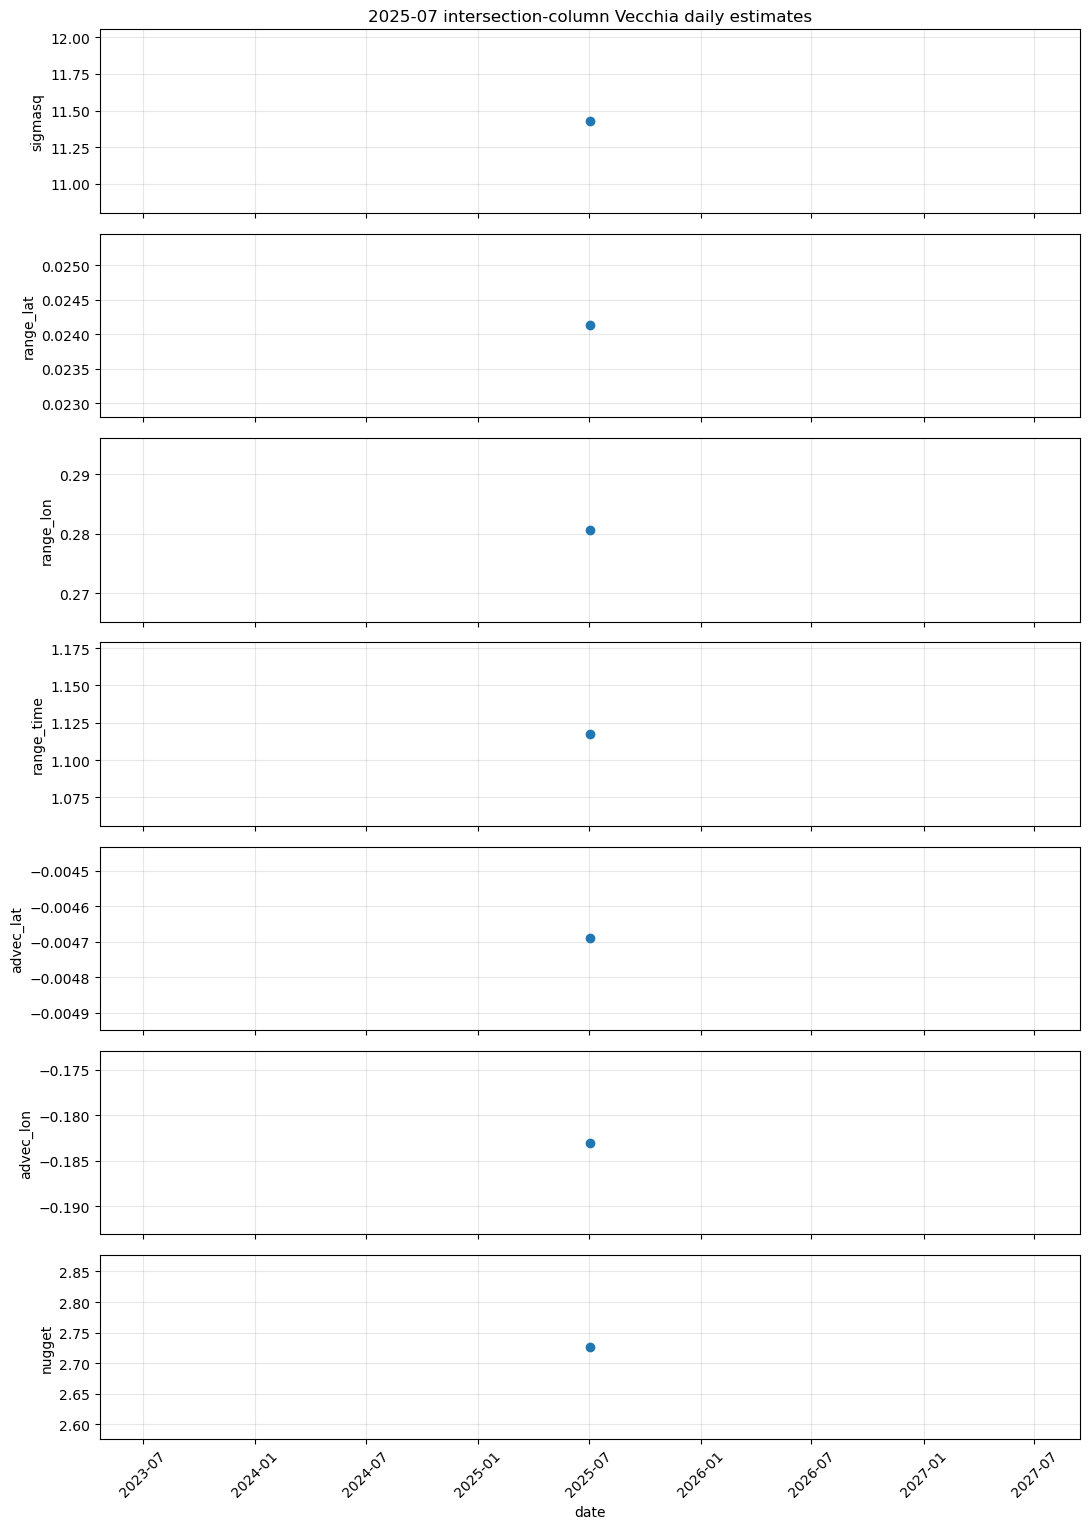

In [9]:
if len(fit_rows):
    cols = ['sigmasq', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget']
    fig, axes = plt.subplots(len(cols), 1, figsize=(11, 2.2 * len(cols)), sharex=True)
    x = pd.to_datetime(fit_df['date'])
    for ax, col in zip(axes, cols):
        ax.plot(x, fit_df[col], marker='o')
        ax.set_ylabel(col)
        ax.grid(alpha=0.3)
    axes[0].set_title(f'{DATA_YEAR:04d}-{DATA_MONTH:02d} intersection-column Vecchia daily estimates')
    axes[-1].set_xlabel('date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [10]:
# Save if desired.
OUT_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/estimates/column_intersection')
OUT_DIR.mkdir(parents=True, exist_ok=True)
if len(fit_rows):
    out_csv = OUT_DIR / f'{DATA_YEAR:04d}_{DATA_MONTH:02d}_column_intersection_vecchia_estimates.csv'
    fit_df.round(6).to_csv(out_csv, index=False)
    print('saved', out_csv)


saved /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/estimates/column_intersection/2025_07_column_intersection_vecchia_estimates.csv
